In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (12, 4)
sns.set_style('whitegrid')

df = pd.read_parquet('/Users/anish/Documents/demand forcasting time series /data/processed/features.parquet')
print("Shape:", df.shape)
print("Date range:", df['ts'].min(), "→", df['ts'].max())
print("Hubs:", df['hub_id'].nunique())
df.head(2)

Shape: (66092, 36)
Date range: 2021-01-15 02:00:00 → 2021-04-30 23:00:00
Hubs: 26


,hub_id,ts,orders,hub_name,hub_city,hub_state,hub_dominant_segment,hub_dominant_channel,hour,dow,day,month,week,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,is_active_window,is_dead_window,is_evening_peak,is_late_night,is_holiday,is_payday_window,lag_1,lag_24,lag_168,roll_mean_24,roll_mean_168,roll_std_24,roll_std_168,roll_max_24,lag_336,same_hour_2w_mean,hub_total_orders,hub_avg_hourly
0,3,2021-01-15 02:00:00,4,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE,2,4,15,1,2,0,0.500000,0.866025,-0.433884,-0.900969,0,1,0,0,0,0,4.0,1.0,9.0,5.625,6.940476,8.101597,10.234205,30.0,0.0,4.5,20280,7.04656
1,3,2021-01-15 03:00:00,4,GREEN SHOPPING,PORTO ALEGRE,RS,FOOD,MARKETPLACE,3,4,15,1,2,0,0.707107,0.707107,-0.433884,-0.900969,0,1,0,0,0,0,4.0,1.0,3.0,5.750,6.910714,8.050115,10.235450,30.0,0.0,1.5,20280,7.04656


In [2]:
cutoff = df['ts'].max() - pd.Timedelta(days=14)

train = df[df['ts'] <= cutoff].copy()
test  = df[df['ts'] >  cutoff].copy()

print("Train range:", train['ts'].min(), "→", train['ts'].max())
print("Test  range:", test['ts'].min(),  "→", test['ts'].max())
print("Train rows :", len(train))
print("Test  rows :", len(test))

Train range: 2021-01-15 02:00:00 → 2021-04-16 23:00:00
Test  range: 2021-04-17 00:00:00 → 2021-04-30 23:00:00
Train rows : 57356
Test  rows : 8736


In [3]:
target = 'orders'

exclude = ['ts','hub_name','hub_total_orders','orders']
features = [c for c in df.columns if c not in exclude]

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

print("Number of features:", len(features))
print("Feature list:")
print(features)

Number of features: 32
Feature list:
['hub_id', 'hub_city', 'hub_state', 'hub_dominant_segment', 'hub_dominant_channel', 'hour', 'dow', 'day', 'month', 'week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_active_window', 'is_dead_window', 'is_evening_peak', 'is_late_night', 'is_holiday', 'is_payday_window', 'lag_1', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_mean_168', 'roll_std_24', 'roll_std_168', 'roll_max_24', 'lag_336', 'same_hour_2w_mean', 'hub_avg_hourly']


In [4]:
baseline_pred = X_test['lag_168'].values

baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_wape = np.abs(y_test - baseline_pred).sum() / y_test.sum()

print(f"Baseline (seasonal naive) — same hour, 1 week ago")
print(f"  MAE  : {baseline_mae:.3f}")
print(f"  RMSE : {baseline_rmse:.3f}")
print(f"  WAPE : {baseline_wape*100:.2f}%")

Baseline (seasonal naive) — same hour, 1 week ago
  MAE  : 2.220
  RMSE : 4.434
  WAPE : 43.41%


In [5]:
baseline2_pred = X_test['roll_mean_168'].values

baseline2_mae  = mean_absolute_error(y_test, baseline2_pred)
baseline2_wape = np.abs(y_test - baseline2_pred).sum() / y_test.sum()

print(f"Baseline #2 (7-day rolling mean)")
print(f"  MAE  : {baseline2_mae:.3f}")
print(f"  WAPE : {baseline2_wape*100:.2f}%")

Baseline #2 (7-day rolling mean)
  MAE  : 5.650
  WAPE : 110.49%


In [6]:
model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='poisson',
    random_state=42,
    verbose=-1
)

cat_features = ['hub_id','hub_city','hub_state','hub_dominant_segment','hub_dominant_channel']

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

Training until validation scores don't improve for 100 rounds
[200]	valid_0's poisson: -8.09158
[400]	valid_0's poisson: -8.11404
[600]	valid_0's poisson: -8.11631
Early stopping, best iteration is:
[641]	valid_0's poisson: -8.11682


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=3000,
              num_leaves=64, objective='poisson', random_state=42,
              subsample=0.8, verbose=-1)

In [7]:
pred = np.clip(model.predict(X_test), 0, None)

lgbm_mae  = mean_absolute_error(y_test, pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, pred))
lgbm_wape = np.abs(y_test - pred).sum() / y_test.sum()

print(f"LightGBM")
print(f"  MAE  : {lgbm_mae:.3f}")
print(f"  RMSE : {lgbm_rmse:.3f}")
print(f"  WAPE : {lgbm_wape*100:.2f}%")

print(f"\nImprovement over seasonal-naive baseline:")
print(f"  MAE  : {(1 - lgbm_mae/baseline_mae)*100:.1f}%")
print(f"  WAPE : {(1 - lgbm_wape/baseline_wape)*100:.1f}%")

LightGBM
  MAE  : 1.649
  RMSE : 3.195
  WAPE : 32.25%

Improvement over seasonal-naive baseline:
  MAE  : 25.7%
  WAPE : 25.7%


In [8]:
results = pd.DataFrame({
    'Model':    ['Seasonal Naive (lag_168)', '7-day Rolling Mean', 'LightGBM'],
    'MAE':      [baseline_mae, baseline2_mae, lgbm_mae],
    'RMSE':     [baseline_rmse, np.sqrt(mean_squared_error(y_test, baseline2_pred)), lgbm_rmse],
    'WAPE (%)': [baseline_wape*100, baseline2_wape*100, lgbm_wape*100]
}).round(3)
results

,Model,MAE,RMSE,WAPE (%)
0,Seasonal Naive (lag_168),2.220,4.434,43.415
1,7-day Rolling Mean,5.650,7.956,110.491
2,LightGBM,1.649,3.195,32.249


          feature  importance
           hub_id        4414
            lag_1        3126
     roll_mean_24        2973
           lag_24        2459
      roll_std_24        2438
              day        2322
    roll_mean_168        2294
same_hour_2w_mean        2194
         hour_sin        2110
     roll_std_168        1984
             hour        1908
          lag_168        1768
             week        1741
          lag_336        1667
      roll_max_24        1472


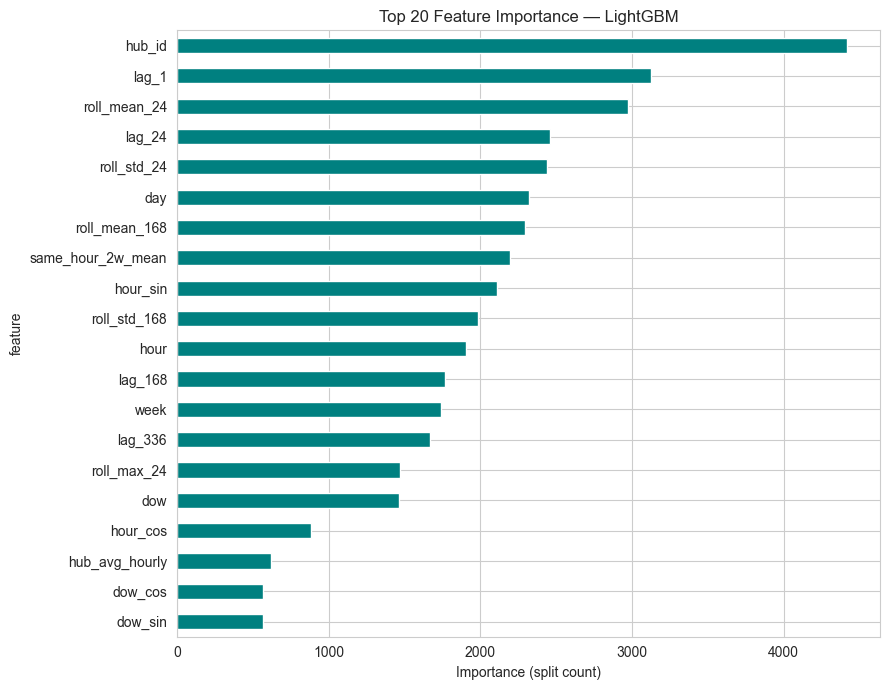

In [9]:
imp = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(imp.head(15).to_string(index=False))

plt.figure(figsize=(9,7))
imp.head(20).iloc[::-1].plot(kind='barh', x='feature', y='importance',
                             color='teal', legend=False, ax=plt.gca())
plt.title('Top 20 Feature Importance — LightGBM')
plt.xlabel('Importance (split count)')
plt.tight_layout()
plt.show()

In [10]:
test_eval = test[['hub_id','hub_name','ts','orders']].copy()
test_eval['pred'] = pred
test_eval['abs_err'] = (test_eval['orders'] - test_eval['pred']).abs()

per_hub = (test_eval.groupby('hub_name', observed=True)
                    .agg(mean_actual=('orders','mean'),
                         mae=('abs_err','mean'),
                         total_actual=('orders','sum'),
                         total_pred=('pred','sum'))
                    .sort_values('total_actual', ascending=False))

per_hub['wape_pct'] = ((per_hub['mae'] * len(test_eval) / per_hub['total_actual']) * 100).round(1)
per_hub['wape_pct'] = per_hub.apply(
    lambda r: round(abs(r['total_actual']-r['total_pred'])/r['total_actual']*100, 1),
    axis=1
)

per_hub.head(20)

,mean_actual,mae,total_actual,total_pred,wape_pct
hub_name,,,,,
GOLDEN SHOPPING,13.502976,2.620088,4537,4505.409514,0.7
SUBWAY SHOPPING,9.586310,2.788776,3221,3338.859864,3.7
COFFEE SHOPPING,8.461310,2.301403,2843,2723.255099,4.2
PAGODE SHOPPING,8.252976,2.719392,2773,2836.608385,2.3
RAP SHOPPING,7.270833,1.817059,2443,2421.730462,0.9
GREEN SHOPPING,7.077381,2.158543,2378,2310.371573,2.8
PEOPLE SHOPPING,6.976190,1.771835,2344,2309.920320,1.5
AVENUE SHOPPING,6.958333,2.129239,2338,2027.588306,13.3
HIP HOP SHOPPING,6.955357,2.097108,2337,2412.580482,3.2


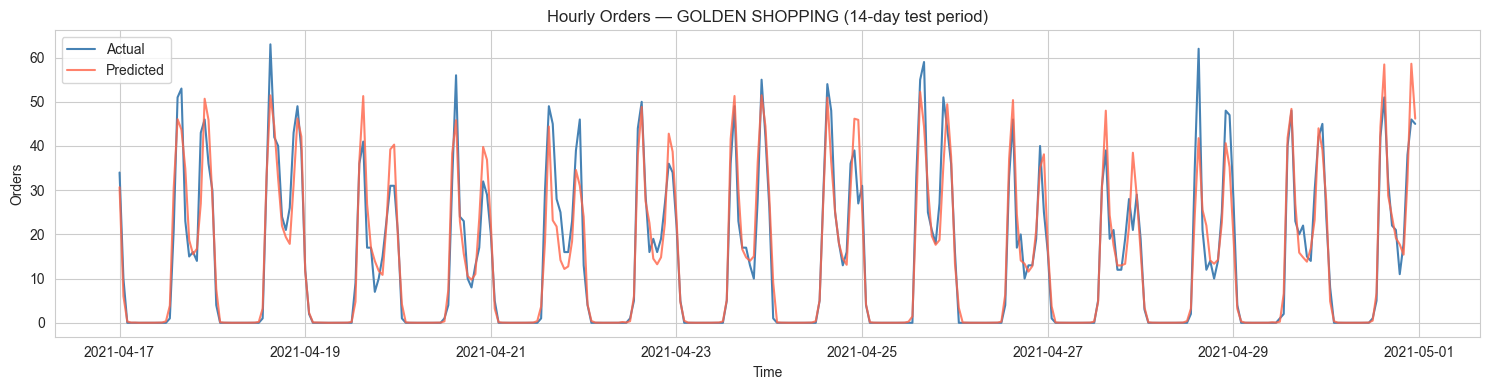

In [11]:
top_hub = per_hub.index[0]
plot_data = test_eval[test_eval['hub_name'] == top_hub].sort_values('ts')

plt.figure(figsize=(15,4))
plt.plot(plot_data['ts'], plot_data['orders'], label='Actual',    linewidth=1.5, color='steelblue')
plt.plot(plot_data['ts'], plot_data['pred'],   label='Predicted', linewidth=1.5, color='tomato', alpha=0.8)
plt.title(f'Hourly Orders — {top_hub} (14-day test period)')
plt.xlabel('Time'); plt.ylabel('Orders'); plt.legend(); plt.tight_layout()
plt.show()

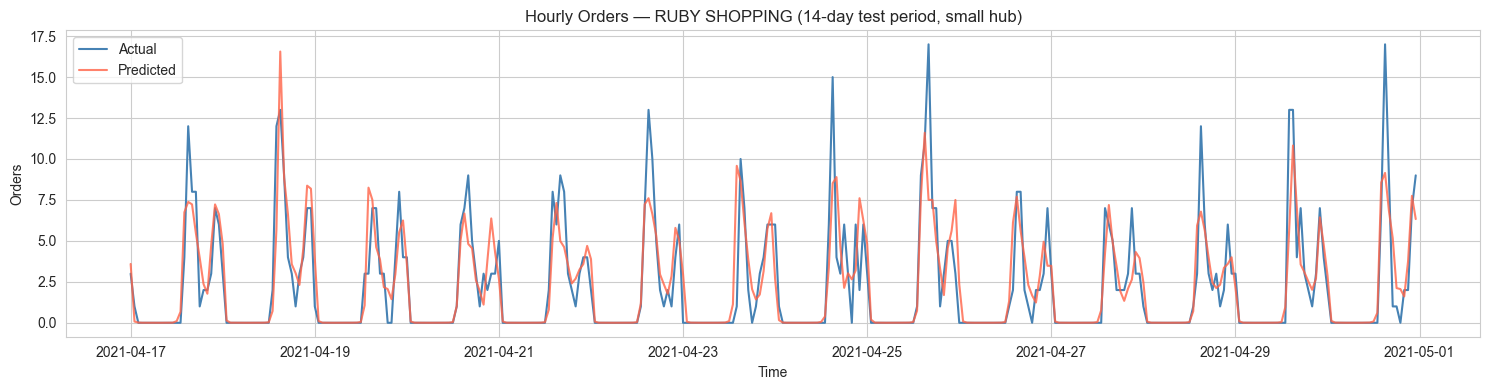

In [12]:
small_hub = per_hub.index[-3]  # bottom hubs (not the very smallest, which may be too noisy)
plot_data2 = test_eval[test_eval['hub_name'] == small_hub].sort_values('ts')

plt.figure(figsize=(15,4))
plt.plot(plot_data2['ts'], plot_data2['orders'], label='Actual',    linewidth=1.5, color='steelblue')
plt.plot(plot_data2['ts'], plot_data2['pred'],   label='Predicted', linewidth=1.5, color='tomato', alpha=0.8)
plt.title(f'Hourly Orders — {small_hub} (14-day test period, small hub)')
plt.xlabel('Time'); plt.ylabel('Orders'); plt.legend(); plt.tight_layout()
plt.show()

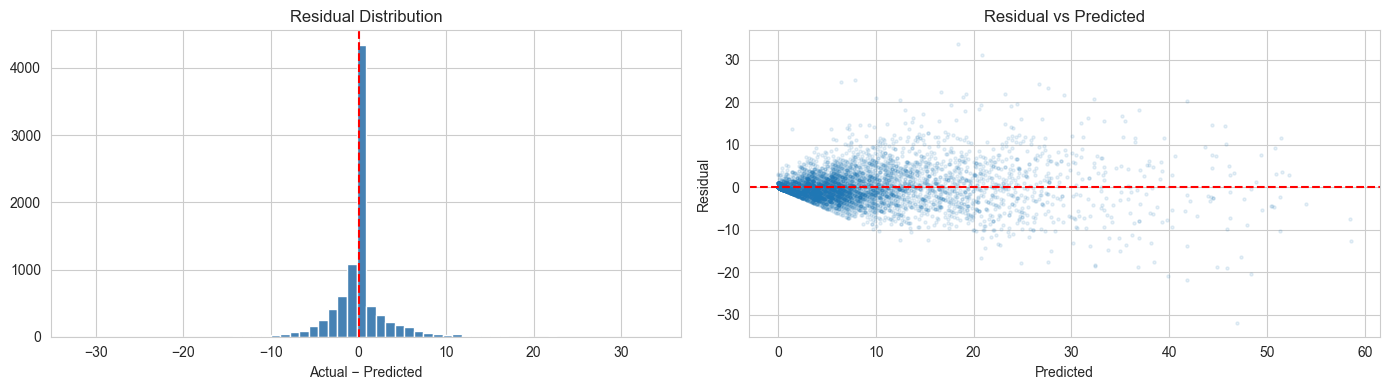

Mean residual : -0.012   (should be near 0)
Std residual  : 3.195


In [13]:
test_eval['residual'] = test_eval['orders'] - test_eval['pred']

fig, ax = plt.subplots(1, 2, figsize=(14,4))

ax[0].hist(test_eval['residual'], bins=60, color='steelblue', edgecolor='white')
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title('Residual Distribution')
ax[0].set_xlabel('Actual − Predicted')

# Residual vs prediction (should be a formless cloud)
ax[1].scatter(test_eval['pred'], test_eval['residual'], alpha=0.1, s=5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Residual')
ax[1].set_title('Residual vs Predicted')

plt.tight_layout(); plt.show()

print(f"Mean residual : {test_eval['residual'].mean():.3f}   (should be near 0)")
print(f"Std residual  : {test_eval['residual'].std():.3f}")

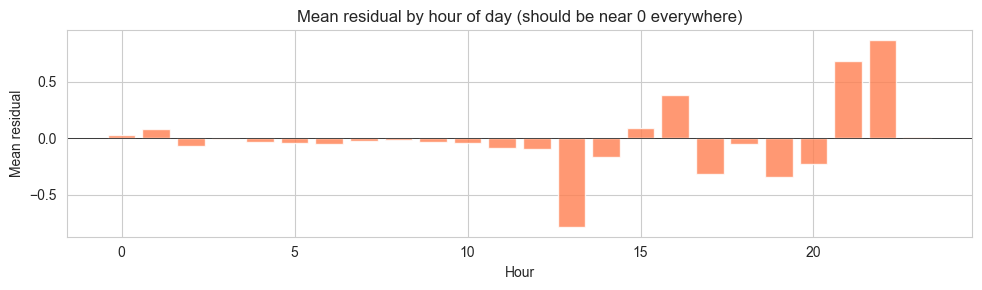

In [14]:
test_eval['hour'] = test_eval['ts'].dt.hour
resid_by_hour = test_eval.groupby('hour')['residual'].agg(['mean','std'])

plt.figure(figsize=(10,3))
plt.bar(resid_by_hour.index, resid_by_hour['mean'], color='coral', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Mean residual by hour of day (should be near 0 everywhere)')
plt.xlabel('Hour'); plt.ylabel('Mean residual')
plt.tight_layout(); plt.show()

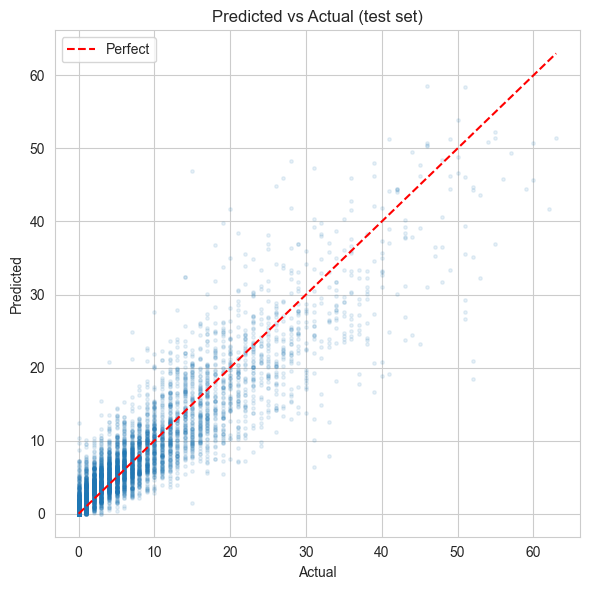

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.1, s=6)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Perfect')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Predicted vs Actual (test set)')
plt.legend(); plt.tight_layout(); plt.show()

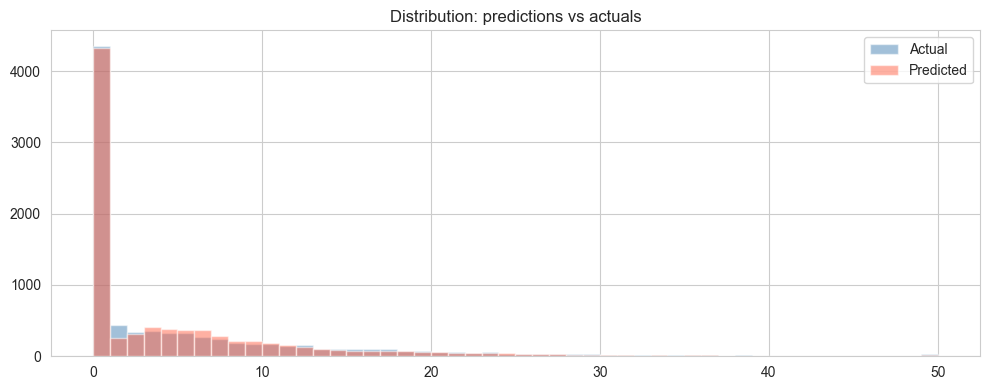

In [16]:
plt.figure(figsize=(10,4))
plt.hist(y_test.clip(upper=50), bins=50, alpha=0.5, label='Actual',    color='steelblue')
plt.hist(pred.clip(max=50),     bins=50, alpha=0.5, label='Predicted', color='tomato')
plt.title('Distribution: predictions vs actuals')
plt.legend(); plt.tight_layout(); plt.show()